# Synthetic kinetic profiles from an equilibrium: fidelity Levels 0–3

A magnetic equilibrium fixes the total pressure $p_\mathrm{eq}(\psi)$, the flux-surface
geometry and $q(\psi)$. It does **not** fix how that pressure splits into
$n_e$, $T_e$, $T_i$ and the ion densities. This notebook builds that split from **declared
assumptions** with `vaft.process.profile.generate_synthetic_kinetic_profiles` (#122), on the
packaged VEST shot 39915 g-file (319 ms) and on an analytic Solov'ev equilibrium.

The fidelity ladder implemented here:

| Level | What sets the profiles | Record |
|---|---|---|
| 0 | $n_e, T_e \propto \sqrt{p_\mathrm{eq}/p_\mathrm{eq}(0)}$, the legacy `core_profiles_from_eq*` closure | `SqrtPressureSplit` |
| 1 | analytic core + pedestal + ITB shapes (#1045 / #552 kernels) or a tabulated profile, used as given | `ProfileSpec(AnalyticProfile \| TabulatedProfile)` |
| 2 | the same shapes normalized to a scalar: axis, separatrix, line or volume average, Greenwald fraction, peaking, $T_i/T_e$, $p_e/p$ | `ScalarTarget`, `peaking_factor`, `TemperatureAssumption` |
| 3 | a prescribed $a/L_f = -d\ln f/dx$, integrated from a boundary value | `GradientProfile` |

Levels 4–6 (empirical closures, an external pedestal model such as EPED, predictive
transport) are **not** implemented. **Nothing in this notebook is measured, fitted or
transport-predicted**: every profile is an assumption that satisfies the constraints it was
asked to satisfy, and the result records which ones and how well.

The pressure constraint is chosen separately:

- `"equilibrium"` — $p_\mathrm{kin} = p_\mathrm{eq}$ **locally**; the closure names the solved
  variable (`"temperature"`, `"density"` or Level 0 `"sqrt_split"`);
- `"thermal_energy"` — a partial constraint: one amplitude makes $W_\mathrm{kin} = W_\mathrm{eq}$;
- `"kinetic"` — the profiles as specified, the mismatch **reported**, never hidden.

Units: m⁻³, eV, Pa, m³. The grid is the source equilibrium's $\psi_N$ (101 points uniform in
$\rho_\mathrm{pol} = \sqrt{\psi_N}$); $\rho_\mathrm{tor}$ is derived from its $q$.

In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vaft.data import (
    Composition, GradientProfile, ProfileSpec, ScalarTarget, SqrtPressureSplit,
    SyntheticKineticSpec, SyntheticProfileError, TemperatureAssumption,
)
from vaft.data.resources import sample_geqdsk
from vaft.process.equilibrium import as_equilibrium, solovev_example
from vaft.process.profile import (
    analytic_hmode_state, compose_analytic_profile, core_profiles_from_eq,
    generate_synthetic_kinetic_profiles, spec_from_plasma_state, write_synthetic_core_profiles,
)


def residual_table(result):
    # Every requested constraint beside the value recomputed from the final profiles.
    rows = [dict(constraint=t.name, requested=t.requested, achieved=t.achieved,
                 relative_residual=t.relative_residual, how=t.solver_status, met=t.met)
            for t in result.targets]
    if not any(t.name == "pressure_closure" for t in result.targets):  # reported even when not requested
        rows.append(dict(constraint="p_kin vs p_eq (local max, reported)", requested=0.0,
                         achieved=result.pressure.max_relative_residual,
                         relative_residual=result.pressure.max_relative_residual,
                         how=result.pressure.mode, met=result.pressure.locally_consistent))
    return pd.DataFrame(rows).set_index("constraint")


def show(result):
    print(f"{result.label}: status={result.status}, level={result.fidelity_level}")
    print(f"  {result.message}")
    print(f"  held={result.pressure.held}\n  solved={result.pressure.solved}")
    return residual_table(result)


gfile = sample_geqdsk()                   # VEST 39915 at 319 ms, packaged EFIT g-file
eq = as_equilibrium(gfile)
T0 = 0.319                                # the g-file carries no time field; the name does

## 1. What the equilibrium gives

$p_\mathrm{eq}(\psi_N)$, the enclosed volume $V(\psi_N)$ from the traced flux surfaces (used for
volume averages and the thermal energy $W = \tfrac32\int p\,dV$), $\rho_\mathrm{tor}$ from $q$ —
which is **not** $\sqrt{\psi_N}$ — and the horizontal chord through the magnetic axis used for
line averages. All of it is read, nothing is changed.

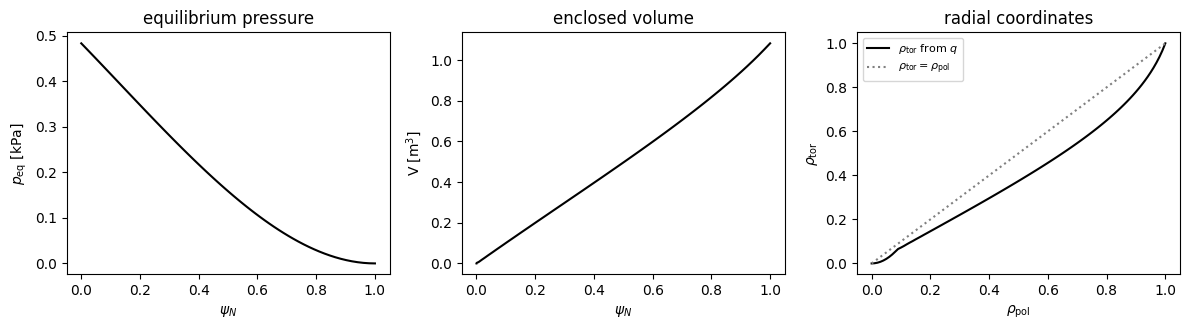

line average : int f dR / (R_out - R_in) on Z = 2.411e-11 m, R in [0.1047, 0.7559] m (axis chord)
volume avg   : int f dV / V, V(psi) the traced flux-surface volume
rho_tor_norm : sqrt(Phi/Phi_boundary), Phi = int q dpsi, from the equilibrium's q
psi (Wb)     : COCOS candidates (1, 2) disagree on psi in COCOS 11; declare the source convention


In [ ]:
probe = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    temperature=TemperatureAssumption(ti_over_te=1.0), pressure_constraint="equilibrium",
    closure="sqrt_split", sqrt_split=SqrtPressureSplit(te_axis=100.0)), time=T0)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].plot(probe.psi_norm, probe.p_eq / 1e3, "k")
ax[0].set(xlabel=r"$\psi_N$", ylabel=r"$p_\mathrm{eq}$ [kPa]", title="equilibrium pressure")
ax[1].plot(probe.psi_norm, probe.volume, "k")
ax[1].set(xlabel=r"$\psi_N$", ylabel="V [m$^3$]", title="enclosed volume")
ax[2].plot(probe.rho_pol_norm, probe.rho_tor_norm, "k", label=r"$\rho_\mathrm{tor}$ from $q$")
ax[2].plot([0, 1], [0, 1], ":", color="0.5", label=r"$\rho_\mathrm{tor} = \rho_\mathrm{pol}$")
ax[2].set(xlabel=r"$\rho_\mathrm{pol}$", ylabel=r"$\rho_\mathrm{tor}$", title="radial coordinates")
ax[2].legend(fontsize=8)
fig.tight_layout()
plt.show()
print("line average :", probe.provenance["line_average"])
print("volume avg   :", probe.provenance["volume_average"])
print("rho_tor_norm :", probe.provenance["rho_tor_norm"])
print("psi (Wb)     :", probe.provenance["psi"])

The g-file's signs leave COCOS 1 and 2 both possible, and those two disagree on the sign of
$\psi$ in COCOS 11, so the generator **leaves $\psi$ out** rather than guessing (§8 shows how to
declare it).

## 2. Level 0 — the legacy square-root split

$n_i = n_e$, $T_i = T_e$, so $p = 2 e n_e T_e$ and $n_e, T_e \propto g = \sqrt{p/p(0)}$ with the
axis $T_e$ fixing the amplitude. This is exactly what `core_profiles_from_eq` writes; the
generator uses the same operations in the same order, so the two agree bit for bit where they
sample the same pressure (the axis). It is a convenient seed, **not** an inference: any other
split of $p$ is equally consistent with the equilibrium.

In [ ]:
legacy = core_profiles_from_eq(gfile.to_omas(), Te0_eV=100.0)
print("axis n_e, legacy helper :", legacy["core_profiles.profiles_1d.0.electrons.density"][0])
print("axis n_e, Level 0 spec  :", probe.n_e[0])
show(probe)

[UPDATED] core_profile from eq pressure (Pa) at 319.000 ms (index 0), eq_time_slice=0
axis n_e, legacy helper : 1.507762645351374e+19
axis n_e, Level 0 spec  : 1.507762645351374e+19
synthetic: status=success, level=0
  p_kin = p_eq locally (max relative residual 2.35e-16)
  held=('shape sqrt(p/p(0)) for n_e and T_e', 'Level 0 amplitude', 'composition', 'T_i route')
  solved=('n_e', 'T_e')


                  requested      achieved  relative_residual    how   met
constraint                                                               
T_i/T_e                 1.0  1.000000e+00       0.000000e+00  local  True
z_eff                   1.0  1.000000e+00       0.000000e+00  local  True
quasineutrality         0.0  0.000000e+00       0.000000e+00  local  True
pressure_closure        0.0  2.353081e-16       2.353081e-16  local  True

## 3. Level 1 — analytic shapes, kinetic closure

An L-mode-like generalized-parabolic density and an H-mode-like temperature with an explicit
core + mtanh pedestal, both from the #1045 composition (`compose_analytic_profile`): the pedestal
top is the knee at `position − width/2`, widths are full widths in $\psi_N$. With
`pressure_constraint="kinetic"` the profiles are kept exactly as given — and the mismatch with
$p_\mathrm{eq}$ is reported.

In [ ]:
ne_L = compose_analytic_profile("n_e", axis_value=1.5e19, separatrix_value=3e18, core_alpha=1.5, core_beta=1.5)
te_H = compose_analytic_profile("T_e", axis_value=180.0, separatrix_value=8.0, pedestal_top_value=70.0,
                                pedestal_position=0.93, pedestal_width=0.05, core_alpha=1.2, core_beta=1.5)
ti_L = compose_analytic_profile("T_i", axis_value=60.0, separatrix_value=5.0, core_beta=2.0)

level1 = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    temperature=TemperatureAssumption(T_i=ProfileSpec(ti_L)), composition=Composition("H"),
    n_e=ProfileSpec(ne_L), T_e=ProfileSpec(te_H), label="Level 1, kinetic"), time=T0)
show(level1)

Level 1, kinetic: status=success, level=1
  kinetic profiles as specified; the source equilibrium is NOT pressure-consistent (max |p_kin - p_eq|/max p_eq = 0.2)
  held=('n_e', 'T_e', 'T_i route', 'composition')
  solved=()


                                     requested  achieved  relative_residual  \
constraint                                                                    
z_eff                                      1.0  1.000000           0.000000   
quasineutrality                            0.0  0.000000           0.000000   
p_kin vs p_eq (local max, reported)        0.0  0.200238           0.200238   

                                         how    met  
constraint                                           
z_eff                                  local   True  
quasineutrality                        local   True  
p_kin vs p_eq (local max, reported)  kinetic  False  

## 4. Level 2 — scalar normalization, and the two closures

Now the shapes stay, the amplitudes are set by physical scalars: the density is normalized to a
**Greenwald fraction** of 0.3 (line average along the axis chord over $n_G = I_p/\pi a^2$) with a
volume **peaking** $n_e(0)/\langle n_e\rangle_V = 1.6$ (solved through the core exponent
$\beta$), $T_i/T_e = 0.5$ (assumed), and a deuterium plasma with carbon at $Z_\mathrm{eff} = 2$.

The same density assumptions are run twice: once in kinetic mode with a prescribed $T_e$
(axis value 150 eV), once with `pressure_constraint="equilibrium", closure="temperature"`, where
$T_e(\psi)$ is **solved** so that $p_\mathrm{kin} = p_\mathrm{eq}$ at every point. Giving a $T_e$
as well would fix the same quantity twice, and is refused (§7).

In [ ]:
density = ProfileSpec(ne_L, ScalarTarget("greenwald_fraction", 0.3), peaking_factor=1.6)
common = dict(temperature=TemperatureAssumption(ti_over_te=0.5), composition=Composition("D", "C", z_eff=2.0),
              n_e=density)
kinetic = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    T_e=ProfileSpec(te_H, ScalarTarget("axis", 150.0)), label="Level 2, kinetic", **common), time=T0)
closed = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    pressure_constraint="equilibrium", closure="temperature", label="Level 2, equilibrium", **common), time=T0)
display(show(kinetic))
show(closed)

Level 2, kinetic: status=success, level=2
  kinetic profiles as specified; the source equilibrium is NOT pressure-consistent (max |p_kin - p_eq|/max p_eq = 0.343)
  held=('n_e', 'T_e', 'T_i route', 'composition')
  solved=()


                                     requested      achieved  \
constraint                                                     
n_e.peaking_factor                         1.6  1.600000e+00   
n_e.greenwald_fraction                     0.3  3.000000e-01   
T_e.axis                                 150.0  1.500000e+02   
T_i/T_e                                    0.5  5.000000e-01   
z_eff                                      2.0  2.000000e+00   
quasineutrality                            0.0  1.097860e-16   
p_kin vs p_eq (local max, reported)        0.0  3.427219e-01   

                                     relative_residual      how    met  
constraint                                                              
n_e.peaking_factor                        2.775558e-16   brentq   True  
n_e.greenwald_fraction                    1.850372e-16   linear   True  
T_e.axis                                  0.000000e+00   linear   True  
T_i/T_e                                   0.000000e+00    

Level 2, equilibrium: status=success, level=2
  p_kin = p_eq locally (max relative residual 1.18e-16)
  held=('n_e', 'composition', 'T_i route')
  solved=('T_e(psi)', 'T_i')


                        requested      achieved  relative_residual     how  \
constraint                                                                   
n_e.peaking_factor            1.6  1.600000e+00       2.775558e-16  brentq   
n_e.greenwald_fraction        0.3  3.000000e-01       1.850372e-16  linear   
T_i/T_e                       0.5  5.000000e-01       0.000000e+00   local   
z_eff                         2.0  2.000000e+00       2.220446e-16   local   
quasineutrality               0.0  1.097860e-16       1.097860e-16   local   
pressure_closure              0.0  1.176540e-16       1.176540e-16   local   

                         met  
constraint                    
n_e.peaking_factor      True  
n_e.greenwald_fraction  True  
T_i/T_e                 True  
z_eff                   True  
quasineutrality         True  
pressure_closure        True  

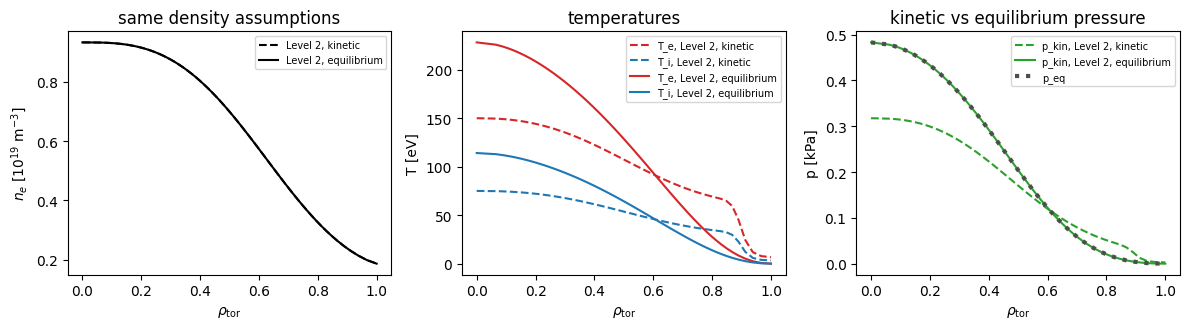

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for r, style in ((kinetic, "--"), (closed, "-")):
    ax[0].plot(r.rho_tor_norm, r.n_e / 1e19, "k" + style, label=r.label)
    ax[1].plot(r.rho_tor_norm, r.T_e, "C3" + style, label=f"T_e, {r.label}")
    ax[1].plot(r.rho_tor_norm, r.T_i, "C0" + style, label=f"T_i, {r.label}")
    ax[2].plot(r.rho_tor_norm, r.p_total / 1e3, "C2" + style, label=f"p_kin, {r.label}")
ax[2].plot(closed.rho_tor_norm, closed.p_eq / 1e3, ":", color="0.3", lw=3, label="p_eq")
ax[0].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel=r"$n_e$ [$10^{19}$ m$^{-3}$]", title="same density assumptions")
ax[1].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel="T [eV]", title="temperatures")
ax[2].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel="p [kPa]", title="kinetic vs equilibrium pressure")
for a in ax:
    a.legend(fontsize=7)
fig.tight_layout()
plt.show()

Composition and pressure partition of the closed state. Quasi-neutrality
$n_e = n_D + 6 n_C$ and $Z_\mathrm{eff} = (n_D + 36 n_C)/n_e$ hold to rounding; carbon at
$Z_\mathrm{eff} = 2$ is $n_C/n_e = 1/30$ and dilutes the deuterium to $0.8\,n_e$.

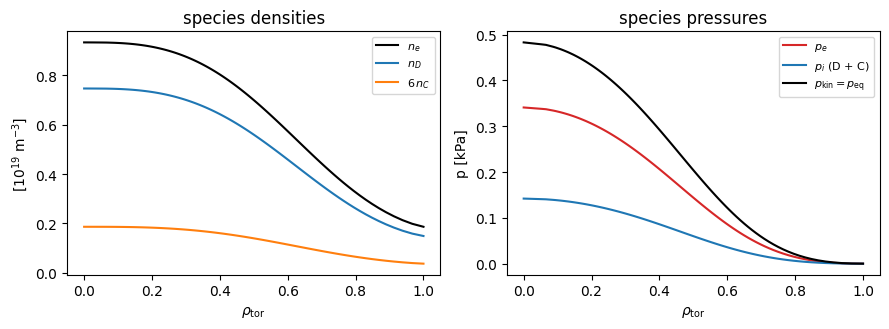

n_C/n_e = 0.03333333333333333  max |n_e - n_D - 6 n_C|/max n_e = 1.0978595099865195e-16


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(closed.rho_tor_norm, closed.n_e / 1e19, "k", label=r"$n_e$")
ax[0].plot(closed.rho_tor_norm, closed.n_i / 1e19, "C0", label=r"$n_D$")
ax[0].plot(closed.rho_tor_norm, 6 * closed.n_impurity / 1e19, "C1", label=r"$6\,n_C$")
ax[0].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel=r"[$10^{19}$ m$^{-3}$]", title="species densities")
ax[1].plot(closed.rho_tor_norm, closed.p_e / 1e3, "C3", label=r"$p_e$")
ax[1].plot(closed.rho_tor_norm, closed.p_i / 1e3, "C0", label=r"$p_i$ (D + C)")
ax[1].plot(closed.rho_tor_norm, closed.p_total / 1e3, "k", label=r"$p_\mathrm{kin} = p_\mathrm{eq}$")
ax[1].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel="p [kPa]", title="species pressures")
for a in ax:
    a.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("n_C/n_e =", closed.n_impurity[0] / closed.n_e[0], " max |n_e - n_D - 6 n_C|/max n_e =",
      closed.validation["quasineutrality_max_relative"])

A **partial** constraint, `thermal_energy`: the prescribed shapes are kept and one temperature
amplitude is chosen so that $W_\mathrm{kin} = W_\mathrm{eq}$. The integral agrees; the local
profile does not, and the result says so (`locally_consistent = False`) instead of claiming
consistency.

In [ ]:
energy = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    T_e=ProfileSpec(te_H), pressure_constraint="thermal_energy", closure="temperature_amplitude",
    label="Level 2, thermal energy", **common), time=T0)
show(energy)

Level 2, thermal energy: status=success, level=2
  W_kin = W_eq; locally NOT pressure-consistent (max relative residual 0.208)
  held=('n_e', 'T_e shape', 'T_i shape or route', 'composition')
  solved=('one amplitude of T_e and T_i',)


                                      requested      achieved  \
constraint                                                      
n_e.peaking_factor                     1.600000  1.600000e+00   
n_e.greenwald_fraction                 0.300000  3.000000e-01   
T_i/T_e                                0.500000  5.000000e-01   
z_eff                                  2.000000  2.000000e+00   
quasineutrality                        0.000000  1.097860e-16   
thermal_energy                       280.213909  2.802139e+02   
p_kin vs p_eq (local max, reported)    0.000000  2.076516e-01   

                                     relative_residual             how    met  
constraint                                                                     
n_e.peaking_factor                        2.775558e-16          brentq   True  
n_e.greenwald_fraction                    1.850372e-16          linear   True  
T_i/T_e                                   0.000000e+00           local   True  
z_eff         

## 5. Level 3 — gradient-based construction

$T_e$ from a piecewise-linear $a/L_{T_e}(\rho_\mathrm{tor}) = -d\ln T_e/d\rho_\mathrm{tor}$:
zero on axis rising to 3 by $\rho = 0.3$, flat to 0.85 (the stiff-core picture), then 10 in an
edge layer, integrated inward from $T_e = 15$ eV at the separatrix and then **scaled** to a
volume average of 60 eV — scaling leaves every $a/L$ unchanged. The logarithmic gradient
reconstructed from the result by finite differences reproduces the prescription except at the
knots, where the prescribed gradient has a kink.

The gradients are *chosen*; nothing here solved a transport equation, so the profile is labelled
an assumption (`transport_predicted = False`), not a prediction.

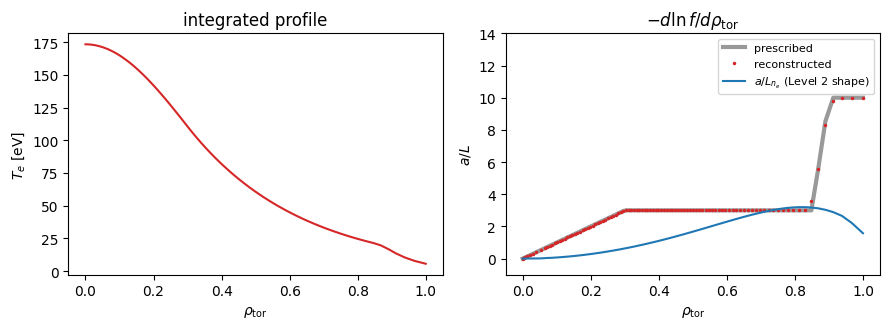

integrated prescribed a/L in rho_tor_norm (assumed, not transport-predicted), scaled to volume_average = 60
Level 3, kinetic: status=success, level=3
  kinetic profiles as specified; the source equilibrium is NOT pressure-consistent (max |p_kin - p_eq|/max p_eq = 0.318)
  held=('n_e', 'T_e', 'T_i route', 'composition')
  solved=()


                                     requested      achieved  \
constraint                                                     
n_e.peaking_factor                         1.6  1.600000e+00   
n_e.greenwald_fraction                     0.3  3.000000e-01   
T_e.volume_average                        60.0  6.000000e+01   
T_i/T_e                                    0.5  5.000000e-01   
z_eff                                      2.0  2.000000e+00   
quasineutrality                            0.0  1.097860e-16   
p_kin vs p_eq (local max, reported)        0.0  3.179424e-01   

                                     relative_residual      how    met  
constraint                                                              
n_e.peaking_factor                        2.775558e-16   brentq   True  
n_e.greenwald_fraction                    1.850372e-16   linear   True  
T_e.volume_average                        0.000000e+00   linear   True  
T_i/T_e                                   0.000000e+00    

In [ ]:
grad = GradientProfile(x=[0.0, 0.3, 0.85, 0.9, 1.0], a_over_L=[0.0, 3.0, 3.0, 10.0, 10.0],
                       boundary_value=15.0, boundary_position=1.0, coordinate="rho_tor_norm")
level3 = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    T_e=ProfileSpec(grad, ScalarTarget("volume_average", 60.0)), label="Level 3, kinetic", **common),
    time=T0)

x = level3.rho_tor_norm
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(x, level3.T_e, "C3")
ax[0].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel=r"$T_e$ [eV]", title="integrated profile")
ax[1].plot(x, grad.gradient(x), "k", lw=3, alpha=0.4, label="prescribed")
ax[1].plot(x, level3.a_over_L("T_e", "rho_tor_norm"), "C3.", ms=3, label="reconstructed")
ax[1].plot(x, level3.a_over_L("n_e", "rho_tor_norm"), "C0", label=r"$a/L_{n_e}$ (Level 2 shape)")
ax[1].set(xlabel=r"$\rho_\mathrm{tor}$", ylabel=r"$a/L$", title=r"$-d\ln f/d\rho_\mathrm{tor}$", ylim=(-1, 14))
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
print(level3.provenance["channels"]["T_e"])
show(level3)

## 6. The analytic equilibrium: a #1045 preset is a special case

`spec_from_plasma_state` turns any #1045 preset into generator inputs — its three channels as
unnormalized `AnalyticProfile` shapes, `T_i` independent, its composition and grid — so the
generator reproduces the preset exactly (Level 1, kinetic). On the same Solov'ev geometry the
equilibrium closure then gives the temperature that *this* equilibrium's pressure needs for the
preset's density. The Solov'ev example carries no $q$, so $\rho_\mathrm{tor}$ is unavailable and
the plots use $\rho_\mathrm{pol}$; asking for a `rho_tor_norm` coordinate there is refused, not
substituted. The solved temperature carries the preset density's pedestal as a bump just inside
the edge: the Solov'ev $p_\mathrm{eq}$ falls smoothly, so where $n_e$ drops steeply the solved $T_e$
must rise. The closure is exact; whether that split is plausible is the user's judgement, which is
why the held and solved variables are reported.

max |p_generator/p_preset - 1| = 2.220446049250313e-16


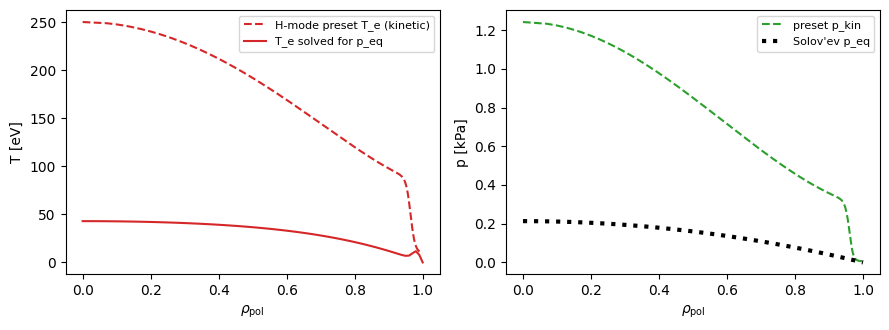

rho_tor_norm: unavailable: finite q on the psi_1d grid is required
Solov'ev, equilibrium closure: status=success, level=2
  p_kin = p_eq locally (max relative residual 2.67e-16)
  held=('n_e', 'composition', 'T_i route')
  solved=('T_e(psi)', 'T_i')


                  requested      achieved  relative_residual    how   met
constraint                                                               
T_i/T_e                 0.6  6.000000e-01       0.000000e+00  local  True
z_eff                   1.5  1.500000e+00       1.480297e-16  local  True
quasineutrality         0.0  1.024000e-16       1.024000e-16  local  True
pressure_closure        0.0  2.666840e-16       2.666840e-16  local  True

In [ ]:
solovev = solovev_example("limited")
preset = analytic_hmode_state(z_eff=1.5)
as_preset = generate_synthetic_kinetic_profiles(solovev, spec_from_plasma_state(preset))
print("max |p_generator/p_preset - 1| =", np.max(np.abs(as_preset.p_total / preset.p_total - 1)))

sv_closed = generate_synthetic_kinetic_profiles(solovev, SyntheticKineticSpec(
    temperature=TemperatureAssumption(ti_over_te=0.6), composition=Composition("H", "C", 1.5),
    n_e=ProfileSpec(preset.profiles["n_e"]), pressure_constraint="equilibrium", closure="temperature",
    label="Solov'ev, equilibrium closure"))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(as_preset.rho_pol_norm, as_preset.T_e, "C3--", label="H-mode preset T_e (kinetic)")
ax[0].plot(sv_closed.rho_pol_norm, sv_closed.T_e, "C3", label="T_e solved for p_eq")
ax[0].set(xlabel=r"$\rho_\mathrm{pol}$", ylabel="T [eV]")
ax[1].plot(as_preset.rho_pol_norm, as_preset.p_total / 1e3, "C2--", label="preset p_kin")
ax[1].plot(sv_closed.rho_pol_norm, sv_closed.p_eq / 1e3, "k:", lw=3, label="Solov'ev p_eq")
ax[1].set(xlabel=r"$\rho_\mathrm{pol}$", ylabel="p [kPa]")
for a in ax:
    a.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("rho_tor_norm:", sv_closed.provenance["rho_tor_norm"])
show(sv_closed)

## 7. Incompatible assumptions are reported, not forced

Two kinds of failure. A **contradictory request** — a prescribed $T_e$ with a closure that solves
$T_e$ — is refused before anything is built. An **incompatible but well-posed** one — ions held
at 2 keV, far above what $p_\mathrm{eq}$ allows at this density — is built, and the closure would
need a negative $T_e$; the result carries `pressure_closure_failed` and cannot be stored.

In [ ]:
try:
    generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
        T_e=ProfileSpec(te_H), pressure_constraint="equilibrium", closure="temperature", **common))
except SyntheticProfileError as err:
    print(err)

hot = generate_synthetic_kinetic_profiles(gfile, SyntheticKineticSpec(
    temperature=TemperatureAssumption(T_i=ProfileSpec(compose_analytic_profile(
        "T_i", axis_value=2000.0, separatrix_value=500.0))),
    n_e=density, pressure_constraint="equilibrium", closure="temperature"), time=T0)
print(f"\n[{hot.status}]", hot.message)
try:
    write_synthetic_core_profiles(hot)
except SyntheticProfileError as err:
    print(f"write refused: [{err.status}]")

try:
    Composition("D", "C", z_eff=7.0)
except SyntheticProfileError as err:
    print("\n" + str(err))

invalid_profile_model: closure='temperature' solves T_e so that p_kin = p_eq; a prescribed T_e contradicts it -- drop it, or keep it with pressure_constraint='kinetic' and read the reported mismatch

[pressure_closure_failed] closure 'temperature' would need a non-positive T_e to reach p_kin = p_eq; the held assumptions are incompatible with the equilibrium pressure
write refused: [pressure_closure_failed]

invalid_composition: Z_eff = 7.0 is unreachable with C6+ in a hydrogenic plasma: it must lie in [1, 6]


## 8. `core_profiles` output

A successful result becomes one `core_profiles.profiles_1d` slice in standard IMAS paths:
`grid.rho_tor_norm` (only where derived from $q$), `grid.rho_pol_norm`, `grid.volume`, and
`grid.psi` in Wb, COCOS 11 **only when the source convention fixes it**; electrons and each ion
with density, temperature and thermal pressure, species charge and mass; `zeff`,
`pressure_thermal`. `ids_properties.comment` states that the slice is synthetic, and
`code.parameters` carries the full provenance as JSON (it survives an IMAS round trip as a
string). Declaring the g-file's convention, here COCOS 1 (an assertion the caller makes, not a
detection), is what allows $\psi$ to be written.

In [ ]:
declared = generate_synthetic_kinetic_profiles(as_equilibrium(gfile, convention=1), SyntheticKineticSpec(
    pressure_constraint="equilibrium", closure="temperature", label="Level 2, equilibrium", **common), time=T0)
ods = write_synthetic_core_profiles(declared)
base = "core_profiles.profiles_1d.0"
for leaf in ("time", "grid.rho_tor_norm", "grid.rho_pol_norm", "grid.psi", "grid.volume",
             "electrons.density", "electrons.temperature", "ion.0.label", "ion.0.density",
             "ion.1.label", "ion.1.z_ion", "ion.1.density", "ion.0.temperature", "zeff", "pressure_thermal"):
    value = ods[f"{base}.{leaf}"]
    print(f"{leaf:22s}", value if np.ndim(value) == 0 else f"[{len(value)}] first {np.asarray(value)[0]:.4g}")
print("\nids_properties.comment:", ods["core_profiles.ids_properties.comment"])
record = json.loads(ods["core_profiles.code.parameters"])["slices"]["0.319000000"]
print({k: record[k] for k in ("profile_basis", "transport_predicted", "fidelity_level", "pressure_constraint",
                              "closure", "solved", "psi")})

time                   0.319
grid.rho_tor_norm      [101] first 0
grid.rho_pol_norm      [101] first 0
grid.psi               [101] first -0.01374
grid.volume            [101] first 0
electrons.density      [101] first 9.327e+18
electrons.temperature  [101] first 228.2
ion.0.label            D
ion.0.density          [101] first 7.462e+18
ion.1.label            C6+
ion.1.z_ion            6.0
ion.1.density          [101] first 3.109e+17
ion.0.temperature      [101] first 114.1
zeff                   [101] first 2
pressure_thermal       [101] first 483.1

ids_properties.comment: Synthetic, assumption-driven kinetic profiles generated from a magnetic equilibrium (vaft #122); not measured, not fitted, not transport-predicted.
{'profile_basis': 'assumed', 'transport_predicted': False, 'fidelity_level': 2, 'pressure_constraint': 'equilibrium', 'closure': 'temperature', 'solved': ['T_e(psi)', 'T_i'], 'psi': 'COCOS 1 -> 11'}


## 9. What was assumed, what was derived

| | Level 2 equilibrium-closed state above |
|---|---|
| **from the equilibrium** | $p_\mathrm{eq}(\psi)$, $\psi_N$, $\rho_\mathrm{tor}$ (via $q$), $V(\psi)$, the axis chord, $I_p$ and $a$ for $n_G$ |
| **assumed** | the $n_e$ shape, its Greenwald fraction and peaking, $T_i/T_e = 0.5$, D + C with uniform $Z_\mathrm{eff} = 2$ |
| **derived** | $T_e(\psi)$ from $p_\mathrm{kin} = p_\mathrm{eq}$, $T_i$, $n_D$, $n_C$, $p_e$, $p_i$ |
| **not used** | any measurement, any empirical closure (Level 4), any pedestal model such as EPED (Level 5), any transport solver (Level 6) |

- A profile from these records is **assumption-driven**: its provenance says
  `profile_basis = "assumed"` and `transport_predicted = False`, including the gradient-based
  Level 3 profile, whose $a/L$ was chosen, not computed.
- An *empirically constrained* profile (Level 4: a density-peaking or $T_i/T_e$ scaling), a
  *pedestal-model-constrained* one (Level 5: EPED height and width) and a *transport-predicted*
  one (Level 6: TGLF/TGYRO) are different claims and follow-up work; they would feed the same
  records, but must say what produced their numbers.
- The equilibrium is never changed. Making the kinetic pressure the equilibrium's pressure is a
  new equilibrium solve: the equilibrium–kinetic iteration of #123, which applies the same
  `SyntheticKineticSpec` to each updated equilibrium.